In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.4f}'.format

In [110]:
train_data = pd.read_csv("data/linear/train_set.csv", index_col=0, parse_dates=True)
test_data = pd.read_csv("data/linear/test_set.csv", index_col=0, parse_dates=True)

train_data.head(10)

,close,volume,pct_change_1d,rsi,adx,corr,volatility,signal
Date,,,,,,,,
2023-02-02,1.7050,8523200,-0.0263,25.7174,20.0382,0.6622,1.5033,1
2023-02-03,1.7511,9219400,0.0270,39.1583,23.3035,0.7018,1.8069,0
2023-02-07,1.6866,11662300,-0.0368,30.5574,27.4843,0.8373,2.0947,1
2023-02-08,1.7050,5665300,0.0109,35.0839,31.2471,0.8722,2.1606,1
2023-02-09,1.7142,6074700,0.0054,37.3526,33.7873,0.8379,2.1827,0
2023-02-10,1.6773,4602400,-0.0215,32.3309,36.5168,0.8342,2.1674,0
2023-02-13,1.6313,4697600,-0.0275,27.2438,39.8342,0.8738,2.2451,0
2023-02-14,1.6128,8820100,-0.0113,25.4632,43.3179,0.9076,2.0694,1
2023-02-15,1.7142,12518500,0.0629,46.7374,43.7566,0.6571,3.1505,0


In [ ]:
# exclude 'close' signal for feature set X and separate 'signal' column out as target y
X_train = train_data.iloc[:, 1:-1].copy()
y_train = pd.DataFrame(train_data['signal'])
X_test = test_data.iloc[:, 1:-1].copy()
y_test = pd.DataFrame(test_data['signal'])

print(f"X_train.shape: {X_train.shape}, y_train.shape: {y_train.shape}\n"
      f"X_test.shape: {X_test.shape}, y_test.shape: {y_test.shape}\n")

print(f"\nrange: \n{round(X_train.max() - X_train.min(), 2)}")
print(f"\nstandard deviation: \n{X_train.std()}")

X_train.shape: (572, 6), y_train.shape: (572, 1)
X_test.shape: (144, 6), y_test.shape: (144, 1)


range: 
volume          97905800.0000
pct_change_1d          0.2200
rsi                   74.1800
adx                   58.1600
corr                   1.7600
volatility             4.7500
dtype: float64

standard deviation: 
volume          8509350.7945
pct_change_1d         0.0206
rsi                  13.3768
adx                  12.0919
corr                  0.4402
volatility            0.8115
dtype: float64


### Feature Scaling using Z-score normalization for features 'volume', 'rsi' and 'adx'.

**Justifications**

Z-score normalization instead of min-max normalization:  
Features chosen for normalization: only 'volume', 'rsi' and 'adx' had values with ranges above 5

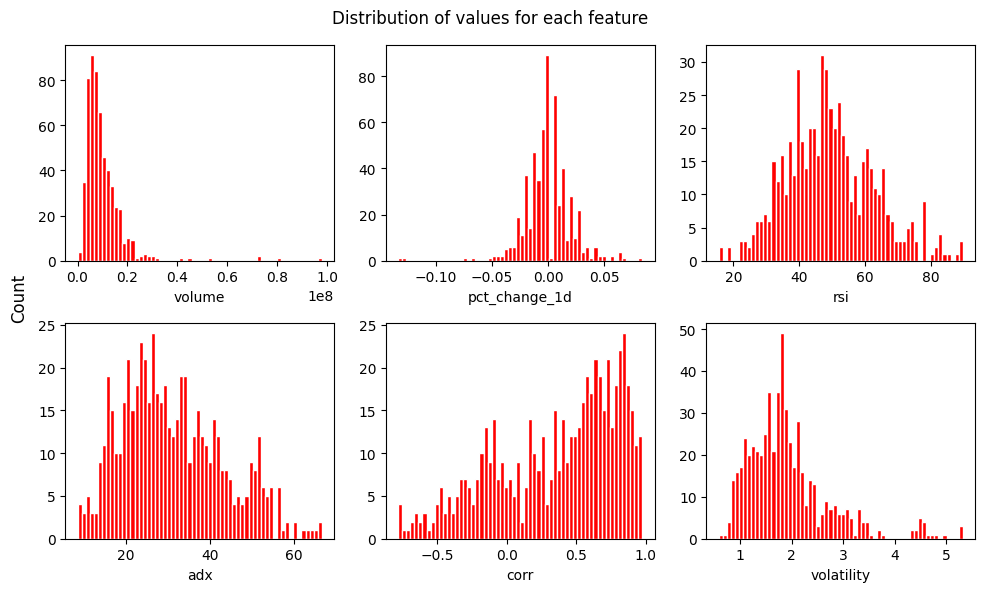

In [112]:
ncolumns = 3
nrows = (X_train.shape[1] + ncolumns-1) // ncolumns
features = X_train.columns

fig, axs = plt.subplots(nrows, ncolumns, figsize=(10, 6))

n=0
for i in range(nrows):
    for j in range(ncolumns):
        axs[i, j].hist(X_train[features[n]], bins=60, color='r', edgecolor='w')
        axs[i, j].set_xlabel(features[n])
        n += 1

fig.supylabel('Count')
fig.suptitle('Distribution of values for each feature')

plt.tight_layout()
plt.show()

In [113]:
def zscore_normalize_features(X: pd.DataFrame, columns: list):
    """
    computes Z-score normalized features by column
    
    Args:
      X (DataFrame (m,n)) : input data, m examples, n features
      columns (list (p))  : names of features to be normalized
      
    Returns:
      X_norm (DataFrame (m,n)) : input with selected columns normalized
      mu (Series (p,1))     : mean of each normalized feature
      sigma (Series (p,1))  : standard deviation of each normalized feature
    """
    
    X_norm = X.copy()
    mu = {}
    sigma = {}

    for feature in columns:
        mu[feature] = X[feature].mean()
        sigma[feature] = X[feature].std()
        X_norm[feature] = (X[feature] - mu[feature]) / sigma[feature]
    
    mu = pd.Series(mu)
    sigma = pd.Series(sigma)
    
    return X_norm, mu, sigma

In [114]:
columns_for_scaling = ['volume', 'adx', 'rsi']

X_train_norm, X_train_mu, X_train_sigma = zscore_normalize_features(X_train, columns_for_scaling)

In [115]:
above = X_train_norm[X_train_norm['volume'] > 5]
print("Length of entries above threshold:", len(above))

m = len(X_train_norm)
X_train_norm.drop(above.index, inplace=True)
print(f"Length of training set.\nBefore: {m}, After: {len(X_train_norm)}\n")

Length of entries above threshold: 5
Length of training set.
Before: 572, After: 567



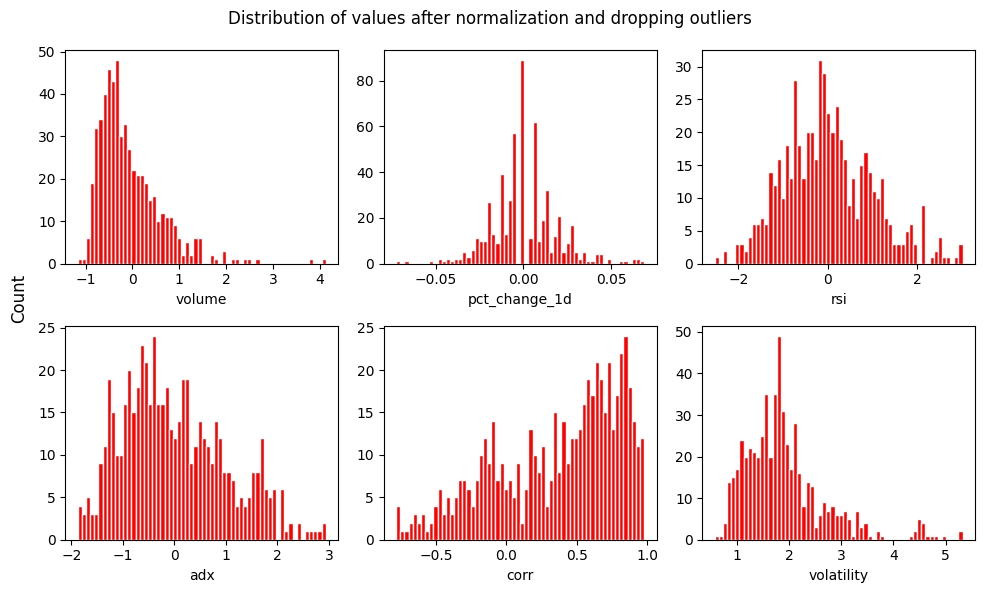

In [116]:
ncolumns = 3
nrows = (X_train_norm.shape[1] + ncolumns-1) // ncolumns
features = X_train_norm.columns

fig, axs = plt.subplots(nrows, ncolumns, figsize=(10, 6))

n=0
for i in range(nrows):
    for j in range(ncolumns):
        axs[i, j].hist(X_train_norm[features[n]], bins=60, color='r', edgecolor='w')
        axs[i, j].set_xlabel(features[n])
        n += 1

fig.supylabel('Count')
fig.suptitle('Distribution of values after normalization and dropping outliers')

plt.tight_layout()
plt.show()

In [117]:
# Resave original training set without dropped entries
X_train_save = X_train.drop(index=above.index)
y_train_save = y_train.drop(index=above.index)

X_train_save.to_csv("data/linear/X_train.csv")
y_train_save.to_csv("data/linear/y_train.csv")
X_test.to_csv("data/linear/X_test.csv")
y_test.to_csv("data/linear/y_test.csv")

Repeat the process for polynomial feature set

In [118]:
train_poly_data = pd.read_csv("data/poly/train_poly_set.csv", index_col=0, parse_dates=True)
test_poly_data = pd.read_csv("data/poly/test_poly_set.csv", index_col=0, parse_dates=True)

train_poly_data.head(5)

,close,volume,pct_change_1d,rsi,adx,corr,volatility,volume^2,pct_change_1d^2,rsi^2,...,pct_change_1d*adx,pct_change_1d*corr,pct_change_1d*volatility,rsi*adx,rsi*corr,rsi*volatility,adx*corr,adx*volatility,corr*volatility,signal
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-02,1.7050,8523200,-0.0263,25.7174,20.0382,0.6622,1.5033,72644938240000,0.0007,661.3851,...,-0.5273,-0.0174,-0.0396,515.3296,17.0313,38.6605,13.2702,30.1230,0.9955,1
2023-02-03,1.7511,9219400,0.0270,39.1583,23.3035,0.7018,1.8069,84997336360000,0.0007,1533.3709,...,0.6298,0.0190,0.0488,912.5231,27.4803,70.7534,16.3538,42.1060,1.2680,0
2023-02-07,1.6866,11662300,-0.0368,30.5574,27.4843,0.8373,2.0947,136009241290000,0.0014,933.7537,...,-1.0126,-0.0308,-0.0772,839.8489,25.5844,64.0073,23.0114,57.5703,1.7538,1
2023-02-08,1.7050,5665300,0.0109,35.0839,31.2471,0.8722,2.1606,32095624090000,0.0001,1230.8814,...,0.3415,0.0095,0.0236,1096.2708,30.6019,75.8033,27.2553,67.5134,1.8846,1
2023-02-09,1.7142,6074700,0.0054,37.3526,33.7873,0.8379,2.1827,36901980090000,0.0000,1395.2134,...,0.1826,0.0045,0.0118,1262.0435,31.2961,81.5294,28.3090,73.7476,1.8288,0


In [ ]:
# exclude 'close' signal for feature set X and separate 'signal' column out as target y
X_poly_train = train_poly_data.iloc[:, 1:-1].copy()
y_poly_train = pd.DataFrame(train_poly_data['signal'])
X_poly_test = test_poly_data.iloc[:, 1:-1].copy()
y_poly_test = pd.DataFrame(test_poly_data['signal'])

print(f"X_poly_train.shape: {X_poly_train.shape}, y_poly_train.shape: {y_poly_train.shape}\n"
      f"X_poly_test.shape : {X_poly_test.shape}, y_poly_test.shape : {y_poly_test.shape}\n")

feature_range = X_poly_train.max() - X_poly_train.min()
std = X_poly_train.std()
print(f"\nrange: \n{feature_range}")
print(f"\nstandard deviation: \n{std}")

X_poly_train.shape: (572, 27), y_poly_train.shape: (572, 1)
X_poly_test.shape : (144, 27), y_poly_test.shape : (144, 1)


range: 
volume                             97905800.0000
pct_change_1d                             0.2172
rsi                                      74.1811
adx                                      58.1563
corr                                      1.7583
volatility                                4.7480
volume^2                   9585545673640000.0000
pct_change_1d^2                           0.0178
rsi^2                                  7804.0848
adx^2                                  4364.0988
corr^2                                    0.9531
volatility^2                             28.0267
volume*pct_change_1d               14798053.3159
volume*rsi                       4082817362.6680
volume*adx                       4076832691.3491
volume*corr                        86668515.5270
volume*volatility                 431128675.1986
pct_change_1d*rsi                    

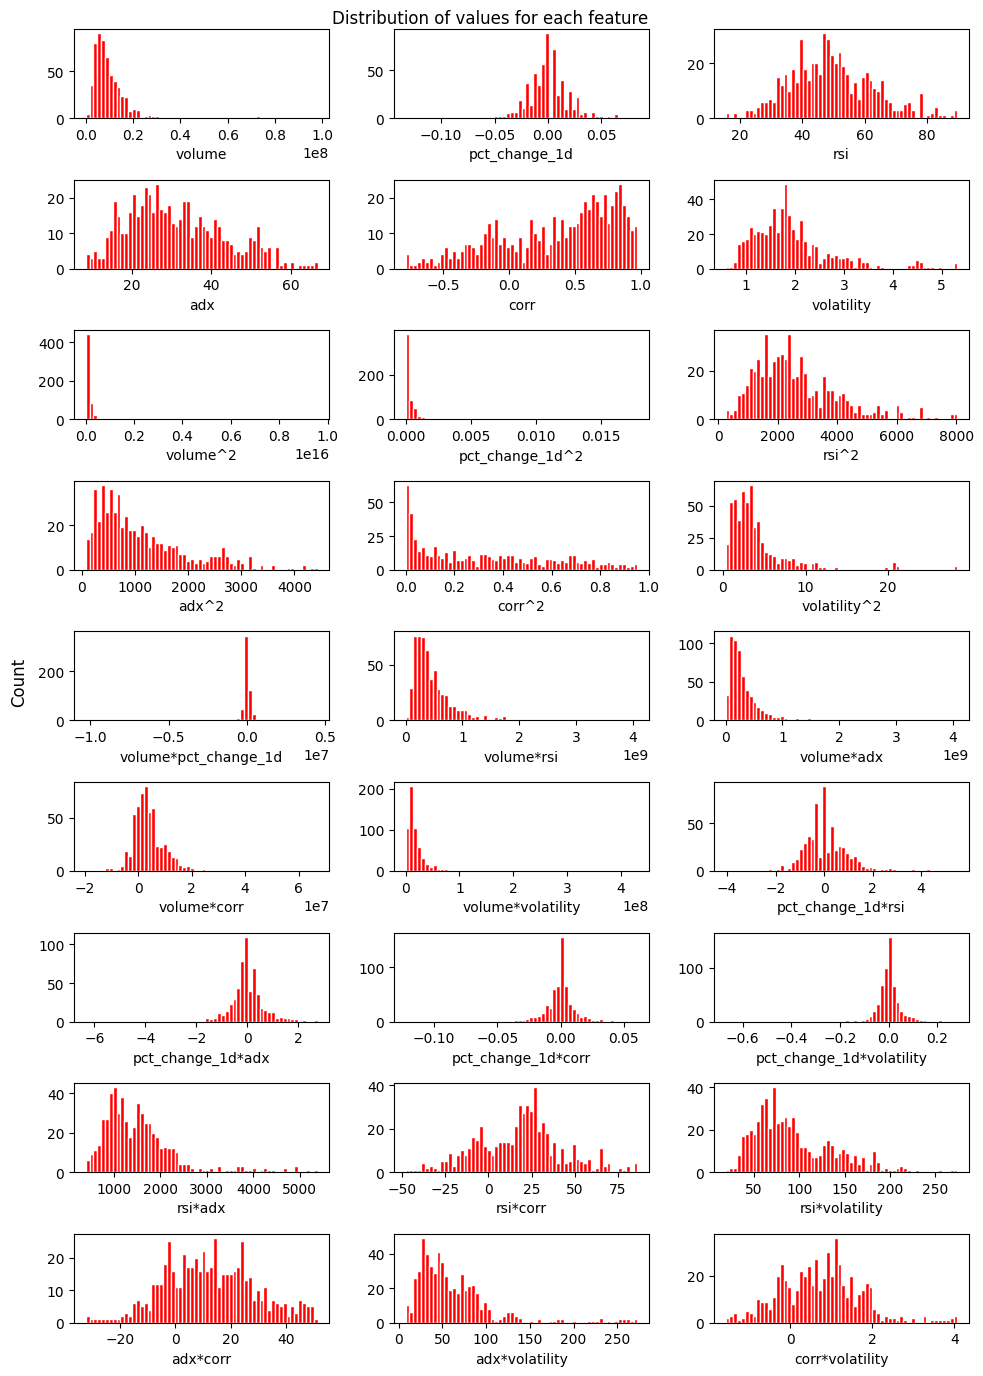

In [120]:
ncolumns = 3
nrows = (X_poly_train.shape[1] + ncolumns-1) // ncolumns
features2 = X_poly_train.columns

fig, axs = plt.subplots(nrows, ncolumns, figsize=(10, 14))

n=0
for i in range(nrows):
    for j in range(ncolumns):
        axs[i, j].hist(X_poly_train[features2[n]], bins=60, color='r', edgecolor='w')
        axs[i, j].set_xlabel(features2[n])
        n += 1

fig.supylabel('Count')
fig.suptitle('Distribution of values for each feature')

plt.tight_layout()
plt.show()

In [121]:
columns_for_scaling2 = []

for name in feature_range.index:
    if feature_range[name] > 5 or feature_range[name] < 0.5:
        columns_for_scaling2.append(name)
    else:
        print(name, "is in acceptable range")
print(f"\ncolumns: {columns_for_scaling2}\nlength: {len(columns_for_scaling2)}")

corr is in acceptable range
volatility is in acceptable range
corr^2 is in acceptable range
pct_change_1d*volatility is in acceptable range

columns: ['volume', 'pct_change_1d', 'rsi', 'adx', 'volume^2', 'pct_change_1d^2', 'rsi^2', 'adx^2', 'volatility^2', 'volume*pct_change_1d', 'volume*rsi', 'volume*adx', 'volume*corr', 'volume*volatility', 'pct_change_1d*rsi', 'pct_change_1d*adx', 'pct_change_1d*corr', 'rsi*adx', 'rsi*corr', 'rsi*volatility', 'adx*corr', 'adx*volatility', 'corr*volatility']
length: 23


In [122]:
X_poly_train_norm, X_poly_train_mu, X_poly_train_sigma = zscore_normalize_features(X_poly_train, columns_for_scaling2)

In [ ]:
above2 = X_poly_train_norm[(X_poly_train_norm.abs() > 5).any(axis=1)] # entries above zscore threshold of 5

print("Length of entries above threshold:", len(above2))
print(above2.index)

m = len(X_poly_train_norm)
X_poly_train_norm.drop(above2.index, inplace=True)
print(f"\nLength of training set:\nBefore: {m}, After: {len(X_poly_train_norm)}\n")

Length of entries above threshold: 10
DatetimeIndex(['2023-05-31', '2023-08-10', '2024-03-15', '2024-05-02',
               '2024-05-07', '2024-11-15', '2025-02-19', '2025-02-28',
               '2025-03-03', '2025-03-04'],
              dtype='datetime64[us]', name='Date', freq=None)

Length of training set:
Before: 572, After: 562



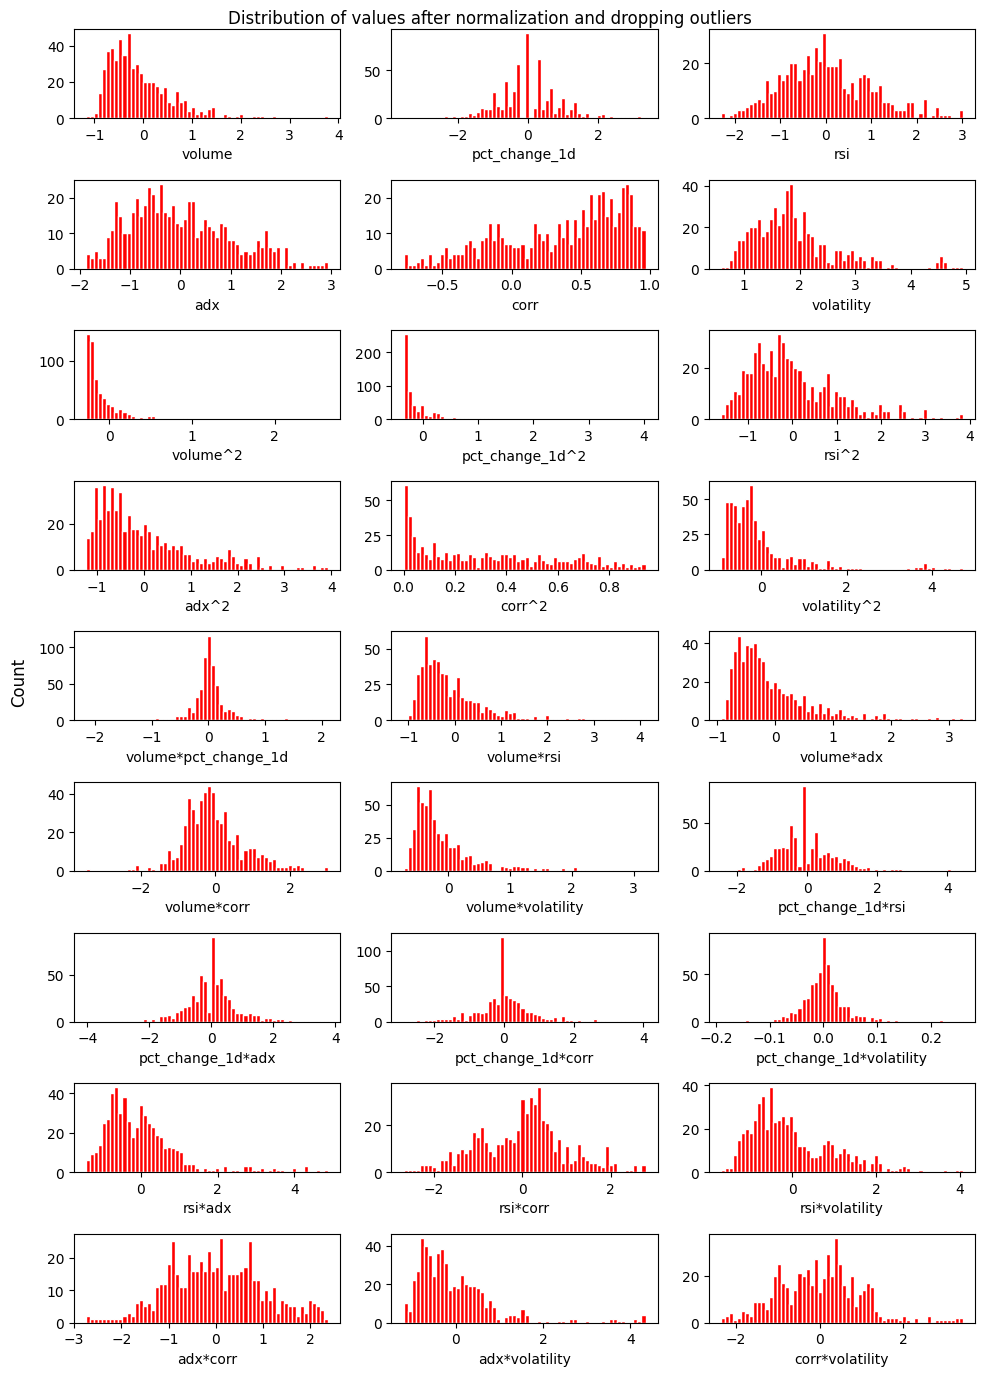

In [124]:
ncolumns = 3
nrows = (X_poly_train_norm.shape[1] + ncolumns-1) // ncolumns
features2 = X_poly_train_norm.columns

fig, axs = plt.subplots(nrows, ncolumns, figsize=(10, 14))

n=0
for i in range(nrows):
    for j in range(ncolumns):
        axs[i, j].hist(X_poly_train_norm[features2[n]], bins=60, color='r', edgecolor='w')
        axs[i, j].set_xlabel(features2[n])
        n += 1

fig.supylabel('Count')
fig.suptitle('Distribution of values after normalization and dropping outliers')

plt.tight_layout()
plt.show()

In [125]:
feature_range = X_poly_train_norm.max() - X_poly_train_norm.min()
std = X_poly_train_norm.std()
print(f"\nrange: \n{feature_range}")
print(f"\nstandard deviation: \n{std}")


range: 
volume                     4.9565
pct_change_1d              6.8928
rsi                        5.3255
adx                        4.8095
corr                       1.7523
volatility                 4.3668
volume^2                   2.9304
pct_change_1d^2            4.3816
rsi^2                      5.4458
adx^2                      5.1686
corr^2                     0.9414
volatility^2               5.6613
volume*pct_change_1d       4.2694
volume*rsi                 5.2221
volume*adx                 4.1783
volume*corr                6.4939
volume*volatility          3.9189
pct_change_1d*rsi          6.9009
pct_change_1d*adx          7.8061
pct_change_1d*corr         6.9482
pct_change_1d*volatility   0.4506
rsi*adx                    6.3133
rsi*corr                   5.4753
rsi*volatility             5.7702
adx*corr                   5.1207
adx*volatility             5.5459
corr*volatility            5.7803
dtype: float64

standard deviation: 
volume                     0.6364
pc

In [126]:
# Resave original unnormalized training set without dropped entries
X_poly_train_save = X_poly_train.drop(index=above2.index)
y_poly_train_save = y_poly_train.drop(index=above2.index)

X_poly_train_save.to_csv("data/poly/X_poly_train.csv")
y_poly_train_save.to_csv("data/poly/y_poly_train.csv")
X_poly_test.to_csv("data/poly/X_poly_test.csv")
y_poly_test.to_csv("data/poly/y_poly_test.csv")